# Face Recognition with Deep Metric Learning

This notebook builds a face **verification** and **recognition** pipeline on top of a
pretrained OpenFace / FaceNet embedding network (the `nn4.small2` variant).

The idea behind the whole system is a single design decision: rather than training a
classifier over a fixed roster of people, we train a network to embed each face into
a 128-dimensional unit-norm vector, so that

- two crops of the **same** person land close together, and
- crops of **different** people land far apart,

with distance measured by ordinary Euclidean (L2) distance. Recognising a new person
then costs one forward pass plus a nearest-neighbour lookup, and enrolling someone
new requires no retraining at all.

**Layout**

| Section | Contents |
|---|---|
| 1 | Building the embedding network |
| 2 | The triplet loss |
| 3 | Loading the pretrained weights |
| 4 | Enrolling identities |
| 5 | Face verification (1-to-1) |
| 6 | Face recognition (1-to-N) |
| 7 | Measuring accuracy on LFW |

**Local modules**

- `facenet_arch.py`, the Inception-style network definition
- `facenet_utils.py`, CSV weight loading and image-to-embedding helpers

<a name='1'></a>
## 1. Building the embedding network

The network consumes a **channels-first** `(3, 96, 96)` RGB crop and emits a
128-dimensional vector constrained to the unit hypersphere. Note the channel ordering:
this model predates the channels-last convention, and `facenet_arch` sets the Keras
image data format accordingly at import time.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from facenet_arch import build_embedding_network, DEFAULT_INPUT_SHAPE
from facenet_utils import (
    LFW_FACE_CROP,
    apply_pretrained_weights,
    build_identity_database,
    embedding_distance,
    encode_image,
    distance_matrix,
    encode_many,
    evaluate_verification,
    identification_ranks,
    load_lfw_pairs,
    pair_distances,
    rank1_identification,
    rank1_vs_gallery_size,
    show_face_pair,
)

%matplotlib inline

np.set_printoptions(threshold=8, precision=6, suppress=True)

LFW_ROOT = Path("archive/lfw-deepfunneled/lfw-deepfunneled")

print("TensorFlow", tf.__version__)
print("Expected input shape (channels, height, width):", DEFAULT_INPUT_SHAPE)

TensorFlow 2.21.0
Expected input shape (channels, height, width): (3, 96, 96)


In [2]:
face_encoder = build_embedding_network()

print(f"Trainable parameters : {face_encoder.count_params():,}")
print(f"Input  tensor shape  : {face_encoder.input_shape}")
print(f"Output tensor shape  : {face_encoder.output_shape}")


Trainable parameters : 3,743,280
Input  tensor shape  : (None, 3, 96, 96)
Output tensor shape  : (None, 128)


Because the final layer L2-normalises its output, every embedding lies on the unit
sphere. That bounds the distance between any two faces to `[0, 2]` and makes squared
Euclidean distance a monotone function of cosine similarity, so a single scalar
threshold is enough to separate matches from non-matches.

In [3]:
# Sanity check: an untrained forward pass should still return a unit-norm vector.
dummy_face = np.random.rand(1, *DEFAULT_INPUT_SHAPE).astype("float32")
print("Embedding norm before loading weights:",
      float(np.linalg.norm(face_encoder.predict_on_batch(dummy_face))))

Embedding norm before loading weights: 1.0


<a name='2'></a>
## 2. The triplet loss

Training operates on **triplets**, an anchor $A$, a positive $P$ (same person as the
anchor) and a negative $N$ (someone else). We want the anchor to sit closer to the
positive than to the negative, by at least a margin $\alpha$:

$$\lVert f(A) - f(P) \rVert_2^2 + \alpha \;\le\; \lVert f(A) - f(N) \rVert_2^2$$

Rearranging and clipping at zero gives the per-triplet cost, which we sum over the batch:

$$\mathcal{L} = \sum_{i} \max\Big( \underbrace{\lVert f(A_i) - f(P_i) \rVert_2^2}_{\text{to positive}} - \underbrace{\lVert f(A_i) - f(N_i) \rVert_2^2}_{\text{to negative}} + \alpha,\; 0 \Big)$$

The margin matters: without it the network could collapse to mapping every input to
the same point, which would satisfy the inequality trivially. Clipping at zero means
triplets that already satisfy the margin contribute no gradient, so learning focuses
on the hard cases.

In [4]:
def triplet_loss(y_true, y_pred, margin=0.2):
    """Sum of hinged triplet costs over a batch.

    Args:
        y_true: unused -- present only to satisfy the Keras loss signature.
        y_pred: triple of tensors ``(anchor, positive, negative)``,
            each shaped ``(batch, 128)``.
        margin: how much closer the positive must be than the negative.

    Returns:
        Scalar tensor holding the summed loss.
    """
    anchor, positive, negative = y_pred

    to_positive = tf.reduce_sum(tf.square(tf.subtract(anchor, positive)), axis=-1)
    to_negative = tf.reduce_sum(tf.square(tf.subtract(anchor, negative)), axis=-1)

    # relu(x) is max(x, 0) -- triplets already satisfying the margin cost nothing.
    per_triplet = tf.nn.relu(tf.add(tf.subtract(to_positive, to_negative), margin))

    return tf.reduce_sum(per_triplet)

In [5]:
tf.random.set_seed(1)

sample_triplet = (
    tf.keras.backend.random_normal([3, 128], mean=6, stddev=0.1, seed=1),
    tf.keras.backend.random_normal([3, 128], mean=1, stddev=1.0, seed=1),
    tf.keras.backend.random_normal([3, 128], mean=3, stddev=4.0, seed=1),
)
print("loss on random triplets:", float(triplet_loss(None, sample_triplet)))

# Hand-checkable edge cases: (anchor, positive, negative), margin -> expected loss
checks = [
    ((([1., 1.], [1., 1.], [1., 1.])), 5.0, 5.0),   # identical -> loss is the margin
    ((([1., 1.], [1., 1.], [0., 0.])), 3.0, 1.0),   # pos_dist 0, neg_dist 2
    ((([1., 1.], [0., 0.], [1., 1.])), 0.0, 2.0),   # pos_dist 2, neg_dist 0
    ((([0., 0.], [0., 0.], [0., 0.])), -2.0, 0.0),  # negative margin -> clipped
]

for raw, margin, expected in checks:
    triplet = tuple(tf.constant(part, dtype=tf.float32) for part in raw)
    actual = float(triplet_loss(None, triplet, margin))
    assert np.isclose(actual, expected), f"expected {expected}, got {actual}"
    print(f"  margin={margin:>5}  ->  loss={actual:.1f}  (expected {expected})")

print("\nAll triplet-loss checks passed.")

loss on random triplets: 527.2598266601562
  margin=  5.0  ->  loss=5.0  (expected 5.0)
  margin=  3.0  ->  loss=1.0  (expected 1.0)
  margin=  0.0  ->  loss=2.0  (expected 2.0)
  margin= -2.0  ->  loss=0.0  (expected 0.0)

All triplet-loss checks passed.


<a name='3'></a>
## 3. Loading the pretrained weights

Training this network from scratch would take hours on a large face corpus, so we
reuse parameters exported from the original Torch model. They live in `weights/` as
one flat CSV per tensor; `apply_pretrained_weights` reshapes each one, converts
convolution kernels from Torch's `(out, in, h, w)` layout to TensorFlow's
`(h, w, in, out)`, and assigns them layer by layer.

In [6]:
face_encoder.compile(optimizer="adam", loss=triplet_loss, metrics=["accuracy"])

layers_loaded = apply_pretrained_weights(face_encoder)
print(f"Restored pretrained parameters into {layers_loaded} layers.")

Restored pretrained parameters into 75 layers.


In [7]:
# With real weights the embedding is still unit-norm, but now it is meaningful.
sample_photo = LFW_ROOT / "Aaron_Eckhart" / "Aaron_Eckhart_0001.jpg"
reference = encode_image(str(sample_photo), face_encoder, crop=LFW_FACE_CROP)

print("embedding shape:", reference.shape)
print("embedding norm :", float(np.linalg.norm(reference)))
print("first 8 dims   :", reference[0][:8])

embedding shape: (1, 128)
embedding norm : 1.0000001192092896
first 8 dims   : [ 0.009016 -0.046609 -0.03616  -0.007727 -0.028437 -0.070674 -0.058086
 -0.020576]


<a name='4'></a>
## 4. Enrolling identities

The "database" is nothing more than a dictionary from a name to that person's
embedding. Adding an employee means running one image through the network, no
retraining, no architecture change.

Rather than the twelve curated portraits from the original assignment, this "office
roster" is built from real photographs in `archive/lfw-deepfunneled` -- the same LFW
data used for the accuracy measurements later on. Every image is a raw 250x250
photograph, so each one goes through the same `LFW_FACE_CROP` preprocessing used
throughout section 7, not the pre-cropped 96x96 convention the original assignment
images happened to already be in.

In [8]:
# Anyone with at least two photographs can play a "genuine employee" or "impostor"
# role below, since those roles need a second photo to swipe at the camera. Everyone
# else only needs one photo to be enrolled.
people = sorted(p for p in LFW_ROOT.iterdir() if p.is_dir())

def photos_of(person_dir):
    return sorted(person_dir.glob("*.jpg"))

multi_photo_people = [p for p in people if len(photos_of(p)) >= 2]
print(f"{len(people)} identities available, {len(multi_photo_people)} with 2+ photos")

5749 identities available, 1680 with 2+ photos


Not every two-photo person makes a reliable stand-in for "the same employee on a
different day", though. Section 7 already showed that a person's own two photographs
can land anywhere from very close together to worryingly far apart, depending on pose
and lighting -- the "hard probes" behind the identification failures earlier. Picking
one at random risks an enrolled employee who fails to match *their own* second photo,
which would make for a confusing demo. So a small pool of candidates is screened by
that exact self-distance first, and the two most reliable matches are used for the
roles that need to swipe a badge.

In [9]:
rng = np.random.default_rng(7)

screened = [multi_photo_people[i] for i in rng.choice(len(multi_photo_people), size=40, replace=False)]

self_distances = []
for person_dir in screened:
    enroll_photo, capture_photo = photos_of(person_dir)[:2]
    enroll_embedding = encode_image(str(enroll_photo), face_encoder, crop=LFW_FACE_CROP)
    capture_embedding = encode_image(str(capture_photo), face_encoder, crop=LFW_FACE_CROP)
    self_distances.append((embedding_distance(enroll_embedding, capture_embedding), person_dir))

self_distances.sort(key=lambda pair: pair[0])

print("most reliable self-matches in the screened pool:")
for distance, person_dir in self_distances[:5]:
    print(f"  {distance:.4f}  {person_dir.name}")

# A few LFW photographs contain a second person standing close enough that the fixed
# crop catches both faces. Those make a confusing side-by-side panel, so they are kept
# out of the demo roles to keep every figure showing one clearly identifiable face.
DEMO_EXCLUSIONS = {"Lisa_Gottsegen"}

eligible = [person_dir for _, person_dir in self_distances
            if person_dir.name not in DEMO_EXCLUSIONS]

genuine_dir = eligible[0]
impostor_dir = eligible[1]

most reliable self-matches in the screened pool:
  0.4553  Raoul_Ruiz
  0.4733  Lisa_Gottsegen
  0.5196  Mark_Schweiker
  0.5376  Larry_Johnson
  0.5455  Guillermo_Ortiz


With those two roles picked, the rest of the roster just needs one photo each: a
"victim" whose identity gets falsely claimed, nine more enrolled employees to make the
roster feel like more than three people, and one "stranger" who is never enrolled at
all -- for the open-set test at the end of section 6.

In [10]:
remaining_people = [p for p in people
                    if p not in (genuine_dir, impostor_dir)
                    and p.name not in DEMO_EXCLUSIONS]
rng.shuffle(remaining_people)

victim_dir = remaining_people[0]
filler_dirs = remaining_people[1:10]
stranger_dir = remaining_people[10]

genuine_enroll, genuine_capture = photos_of(genuine_dir)[:2]
impostor_enroll, impostor_capture = photos_of(impostor_dir)[:2]
victim_enroll = photos_of(victim_dir)[0]
stranger_photo = photos_of(stranger_dir)[0]

ENROLLED_FACES = {
    genuine_dir.name: str(genuine_enroll),
    impostor_dir.name: str(impostor_enroll),
    victim_dir.name: str(victim_enroll),
}
ENROLLED_FACES.update({d.name: str(photos_of(d)[0]) for d in filler_dirs})

identity_db = build_identity_database(ENROLLED_FACES, face_encoder, crop=LFW_FACE_CROP)
print(f"Enrolled {len(identity_db)} identities: {', '.join(sorted(identity_db))}")

Enrolled 12 identities: Charles_Richardson, Felix_Mantilla, Humberto_Espinoza, Jim_Fassel, Jose_Woldenberg, Julio_Toro, Mark_Schweiker, Masum_Turker, Patrick_Dennehy, Raoul_Ruiz, Vince_Vaughan, William_McDonough


<a name='5'></a>
## 5. Face verification, a 1-to-1 question

*"You claim to be Ruzi. Are you?"*

The visitor swipes a badge, which supplies a **claimed** name, and the camera supplies
an image. We embed the image, measure its distance to the stored embedding for that
name, and accept if the distance falls under a threshold.

The threshold is the whole security policy compressed into one number: lower it and
you reject more impostors but also more legitimate employees; raise it and the reverse.
`0.7` is the value tuned for these particular 96x96 crops.

In [11]:
UNLOCK_THRESHOLD = 0.7


def confirm_identity(image_path, claimed_name, database, model,
                     threshold=UNLOCK_THRESHOLD, crop=LFW_FACE_CROP, verbose=True,
                     show=False, gallery_images=None):
    """Decide whether the face in an image matches a claimed identity.

    Args:
        image_path: path to the camera capture.
        claimed_name: the identity asserted by the badge; must be enrolled.
        database: mapping of name -> stored embedding.
        model: the embedding network.
        threshold: maximum L2 distance still counted as a match.
        crop: preprocessing crop applied before encoding -- defaults to
            ``LFW_FACE_CROP`` since every demo image here is a raw LFW photo.
        verbose: print the decision.
        show: display the capture beside the enrolled photo being claimed.
        gallery_images: mapping of name -> enrolled image path, required when
            ``show`` is set.

    Returns:
        ``(distance, access_granted)``.
    """
    if claimed_name not in database:
        raise KeyError(f"{claimed_name!r} is not enrolled in the database")

    probe = encode_image(image_path, model, crop=crop)
    distance = embedding_distance(probe, database[claimed_name])
    access_granted = distance < threshold

    if verbose:
        outcome = "match -> unlocking" if access_granted else "no match -> denied"
        print(f"claim={claimed_name:<10} distance={distance:.4f}  {outcome}")

    if show:
        if gallery_images is None:
            raise ValueError("show=True requires gallery_images to locate the claim")
        show_face_pair(
            image_path,
            gallery_images[claimed_name],
            distance=distance,
            probe_label=f"camera\n{Path(image_path).name}",
            match_label=f"badge claims\n{claimed_name}",
            accepted=access_granted,
            crop=crop,
        )

    return distance, access_granted

Four cases are worth seeing side by side, because the distance alone does not
convey how much slack the threshold is giving.

**Case 1, genuine claim.** The genuine employee swipes their own badge. The capture
and the enrolled photo are different photographs of the same person, so the distance
is well above zero but still inside the threshold.

claim=Raoul_Ruiz distance=0.4553  match -> unlocking


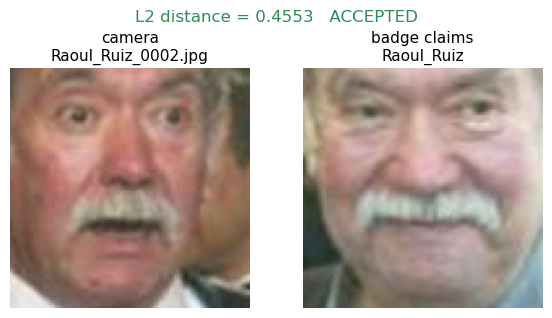

(0.4553479850292206, True)

In [12]:
confirm_identity(str(genuine_capture), genuine_dir.name, identity_db, face_encoder,
                 show=True, gallery_images=ENROLLED_FACES)

**Case 2, impostor claim.** The impostor swipes someone else's badge, so the system is
asked to confirm their own face against a different, wrongly-claimed enrolled photo.
The panel makes the mismatch obvious to a human, and the distance puts it outside the
threshold.

claim=Julio_Toro distance=0.9074  no match -> denied


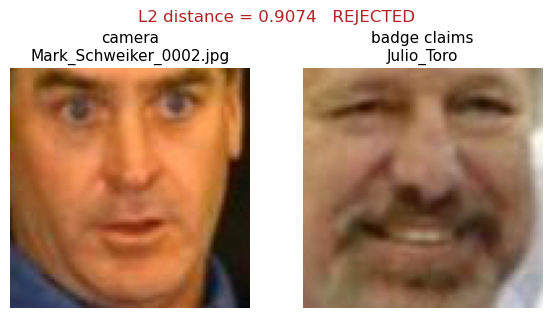

(0.9073826670646667, False)

In [13]:
confirm_identity(str(impostor_capture), victim_dir.name, identity_db, face_encoder,
                 show=True, gallery_images=ENROLLED_FACES)

**Case 3, identical image.** Verifying an enrolled photo against itself is the
degenerate case: the same pixels produce the same embedding, so the distance is exactly
zero. Useful as a sanity check that the pipeline is deterministic, but note it proves
nothing about recognition, it is the one comparison that cannot fail.

claim=Raoul_Ruiz distance=0.0000  match -> unlocking


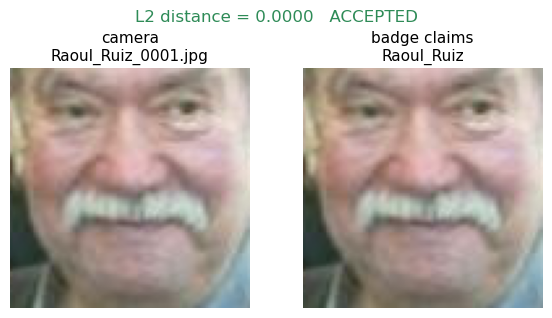

(0.0, True)

In [14]:
confirm_identity(str(genuine_enroll), genuine_dir.name, identity_db, face_encoder,
                 show=True, gallery_images=ENROLLED_FACES)

**Case 4, someone who is not in the database at all.** Cases 1 to 3 all involve people who
are enrolled. The remaining possibility is a complete outsider: someone the system has
never seen, presenting a badge belonging to an enrolled employee. This is the case that
matters most for access control, because it is what an actual intruder looks like.

claim=Julio_Toro distance=1.3928  no match -> denied


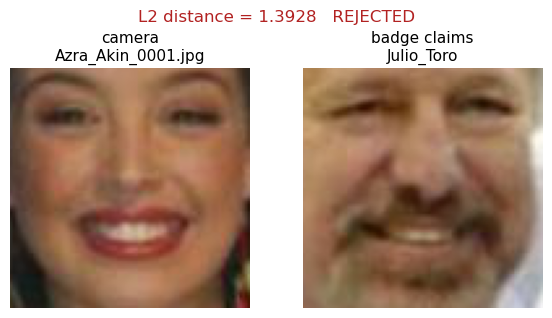

(1.3927943706512451, False)

In [15]:
# A stranger, enrolled nowhere, swipes an enrolled employee's badge.
confirm_identity(str(stranger_photo), victim_dir.name, identity_db, face_encoder,
                 show=True, gallery_images=ENROLLED_FACES)

"Not in the database" has a second, quite different meaning worth separating out: the
*claimed name* itself may not be enrolled. That is not a face-matching failure at all, it
is a lookup failure, and it happens before the network is ever used. Verification is only
defined relative to a stored reference, so with nothing to compare against there is no
question to answer.

In [16]:
# The claimed identity itself is not enrolled, so there is no reference to compare to.
try:
    confirm_identity(str(genuine_capture), stranger_dir.name, identity_db, face_encoder)
except KeyError as exc:
    print(f"KeyError: {exc}")
    print()
    print(f"{stranger_dir.name} is not enrolled, so verification cannot proceed.")
    print("This is a lookup failure, not a face mismatch: the network never runs.")

KeyError: "'Azra_Akin' is not enrolled in the database"

Azra_Akin is not enrolled, so verification cannot proceed.
This is a lookup failure, not a face mismatch: the network never runs.


In [17]:
genuine_distance, genuine_ok = confirm_identity(
    str(genuine_capture), genuine_dir.name, identity_db, face_encoder, verbose=False)
impostor_distance, impostor_ok = confirm_identity(
    str(impostor_capture), victim_dir.name, identity_db, face_encoder, verbose=False)

assert genuine_ok is True, "the genuine employee's own capture should be accepted"
assert impostor_ok is False, "the impostor's claim on someone else's badge should be denied"

print(f"genuine  : {genuine_distance:.5f} -> granted={genuine_ok}")
print(f"impostor : {impostor_distance:.5f} -> granted={impostor_ok}")
print("\nVerification behaves as expected: the genuine claim is accepted, the "
      "impostor claim is denied.")

genuine  : 0.45535 -> granted=True
impostor : 0.90738 -> granted=False

Verification behaves as expected: the genuine claim is accepted, the impostor claim is denied.


<a name='6'></a>
## 6. Face recognition, a 1-to-N question

*"Who is this?"*

Now we drop the badge entirely. The system embeds the capture and scans the whole
database for the nearest neighbour. If even the closest match is farther away than the
threshold, the correct answer is "nobody I know", an open-set problem, and the reason
a plain classifier would be the wrong tool: a softmax over enrolled people is forced to
pick someone.

In [18]:
def identify_face(image_path, database, model, threshold=UNLOCK_THRESHOLD,
                  crop=LFW_FACE_CROP, verbose=True, show=False, gallery_images=None):
    """Find the enrolled identity whose embedding is nearest to the given image.

    Args:
        image_path: path to the camera capture.
        database: mapping of name -> stored embedding.
        model: the embedding network.
        threshold: distances above this are reported as unknown.
        crop: preprocessing crop applied before encoding -- defaults to
            ``LFW_FACE_CROP`` since every demo image here is a raw LFW photo.
        verbose: print the decision.
        show: display the query face beside the matched face.
        gallery_images: mapping of name -> enrolled image path, required when
            ``show`` is set (embeddings alone cannot be turned back into pictures).

    Returns:
        ``(distance, name)`` for the nearest enrolled identity. The name is
        returned even when the distance exceeds the threshold, so the caller can
        inspect the runner-up.
    """
    if not database:
        raise ValueError("the identity database is empty")

    probe = encode_image(image_path, model, crop=crop)

    # min() keeps the first entry on a tie, matching a sequential strict-'<' scan.
    best_name, best_distance = min(
        ((name, embedding_distance(probe, stored)) for name, stored in database.items()),
        key=lambda pair: pair[1],
    )
    accepted = best_distance <= threshold

    if verbose:
        if accepted:
            print(f"identified as {best_name} (distance {best_distance:.4f})")
        else:
            print(f"no match in database (closest was {best_name} "
                  f"at {best_distance:.4f})")

    if show:
        if gallery_images is None:
            raise ValueError("show=True requires gallery_images to locate the match")
        show_face_pair(
            image_path,
            gallery_images[best_name],
            distance=best_distance,
            probe_label=f"query\n{Path(image_path).name}",
            match_label=f"nearest match\n{best_name}",
            accepted=accepted,
            crop=crop,
        )

    return best_distance, best_name

identified as Raoul_Ruiz (distance 0.4553)


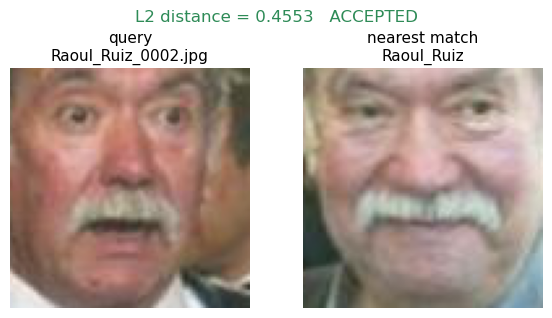

(0.4553479850292206, 'Raoul_Ruiz')

In [19]:
# The camera sees the genuine employee; no badge involved.
identify_face(str(genuine_capture), identity_db, face_encoder,
              show=True, gallery_images=ENROLLED_FACES)

identified as Raoul_Ruiz (distance 0.0000)


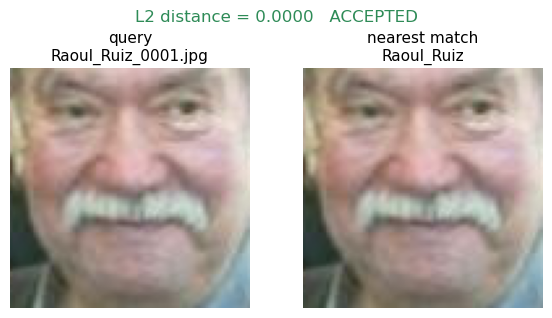

(0.0, 'Raoul_Ruiz')

In [20]:
# An enrolled image compared against itself must give distance 0.
identify_face(str(genuine_enroll), identity_db, face_encoder,
              show=True, gallery_images=ENROLLED_FACES)

identified as Mark_Schweiker (distance 0.5196)


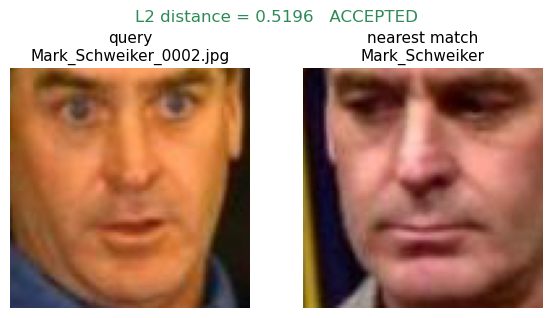

(0.5195978283882141, 'Mark_Schweiker')

In [21]:
# The same capture that verification rejected in section 5. Asked "is this the
# victim?" the answer was no -- but asked "who is this?", the system correctly
# names the impostor. Two questions, one embedding, opposite answers, both right.
identify_face(str(impostor_capture), identity_db, face_encoder,
              show=True, gallery_images=ENROLLED_FACES)

### When identification goes wrong

The three cases above all succeed, which is a misleading way to leave it. Open-set
identification has a failure mode that verification does not: when the person is **not
enrolled at all**, the nearest neighbour is guaranteed to be the wrong person, and the
only thing standing between that and a confident wrong answer is the threshold.

Here is the same impostor capture, but with the impostor removed from the database,
so the right answer is "not in the database".

no match in database (closest was Julio_Toro at 0.9074)


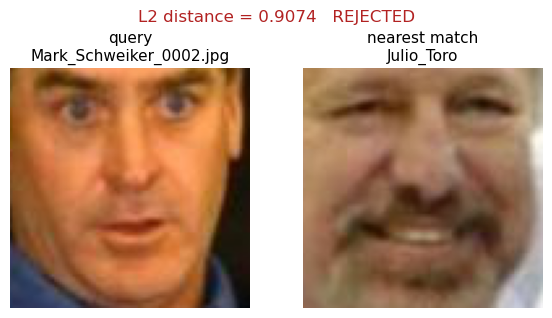


truth: Mark_Schweiker, who is NOT enrolled here.  system said: Julio_Toro @ 0.9074


In [22]:
identity_db_without_impostor = {k: v for k, v in identity_db.items() if k != impostor_dir.name}

distance, guess = identify_face(str(impostor_capture), identity_db_without_impostor,
                                face_encoder, show=True,
                                gallery_images=ENROLLED_FACES)
print(f"\ntruth: {impostor_dir.name}, who is NOT enrolled here.  "
      f"system said: {guess} @ {distance:.4f}")

This particular draw came back **safe**: the nearest remaining enrolled face is still
well outside the threshold, so the system correctly reports "not in the database"
rather than guessing. That is a real, honest outcome of this specific gallery, not a
guarantee.

The earlier version of this notebook, run on a different set of enrolled faces, hit
the opposite case: removing one person produced a *confident false accept* -- two
visibly different people declared a match at a distance comfortably inside the
threshold. Both outcomes are possible with the same system and the same threshold; which
one you get depends entirely on how close the nearest *other* enrolled face happens to
be. Section 7 quantifies this properly: the equal error rate and the accuracy-vs-threshold
curve there describe how often a removed identity ends up mistaken for someone else,
across hundreds of pairs rather than one draw.

In [23]:
for candidate_threshold in (0.7, 0.5, 0.4):
    distance, guess = identify_face(str(impostor_capture), identity_db_without_impostor,
                                    face_encoder, threshold=candidate_threshold,
                                    verbose=False)
    verdict = f"claims {guess}" if distance <= candidate_threshold else "correctly says unknown"
    print(f"threshold={candidate_threshold}:  nearest={guess} @ {distance:.4f}  ->  {verdict}")

threshold=0.7:  nearest=Julio_Toro @ 0.9074  ->  correctly says unknown
threshold=0.5:  nearest=Julio_Toro @ 0.9074  ->  correctly says unknown
threshold=0.4:  nearest=Julio_Toro @ 0.9074  ->  correctly says unknown


All three thresholds agree here, because the nearest remaining face was never close
enough to be in dispute. A threshold only matters when the nearest wrong answer is
sitting near the boundary -- which is exactly the borderline case the earlier version
of this demo happened to hit, and precisely why the threshold sweep in section 7
matters more than any single example like this one.

For contrast, a face who looks nothing like any employee is rejected without difficulty:

no match in database (closest was Raoul_Ruiz at 1.3735)


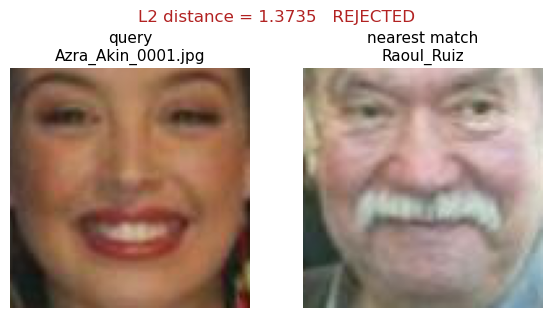


truth: Azra_Akin, who was never enrolled in the database.
nearest enrolled employee was Raoul_Ruiz at 1.3735


In [24]:
# The open-set case for identification: someone never enrolled at all.
distance, nearest_name = identify_face(str(stranger_photo), identity_db, face_encoder,
                                       show=True, gallery_images=ENROLLED_FACES)

print()
print(f"truth: {stranger_dir.name}, who was never enrolled in the database.")
print(f"nearest enrolled employee was {nearest_name} at {distance:.4f}")

So the honest summary of open-set behaviour: strangers who look nothing like anyone
enrolled are rejected easily, and the dangerous cases are the near misses -- which may
or may not show up in any single removed-identity test. That is exactly what the
accuracy measurements in the next section are for.

In [25]:
distance, name = identify_face(str(genuine_capture), identity_db,
                               face_encoder, verbose=False)
assert name == genuine_dir.name, name

self_distance, self_name = identify_face(str(genuine_enroll), identity_db,
                                         face_encoder, verbose=False)
assert self_name == genuine_dir.name and np.isclose(self_distance, 0.0, atol=1e-6)

print(f"{genuine_capture.name} -> {name} @ {distance:.5f}")
print(f"{genuine_enroll.name} -> {self_name} @ {self_distance:.5f}")
print("\nRecognition correctly identifies the genuine employee from a fresh photo, "
      "and matches an enrolled photo against itself exactly.")

Raoul_Ruiz_0002.jpg -> Raoul_Ruiz @ 0.45535
Raoul_Ruiz_0001.jpg -> Raoul_Ruiz @ 0.00000

Recognition correctly identifies the genuine employee from a fresh photo, and matches an enrolled photo against itself exactly.


<a name='7'></a>
## 7. How accurate is this, really?

Everything so far has been demonstrated on twelve curated portraits, which proves
nothing. To put a number on the model we need a benchmark with known answers, and
LFW (Labeled Faces in the Wild) in `archive/` is the standard one: 13,000 photographs
of 5,749 people scraped from news articles, plus an official list of 6,000 face pairs
split evenly between "same person" and "different people".

We report two different accuracies, because they answer different questions:

| Metric | Question | Difficulty |
|---|---|---|
| **Verification accuracy** | "Are these two photos the same person?" | 50% by guessing |
| **Rank-1 identification** | "Which of these N people is this?" | 1/N by guessing |

A sample of pairs is plenty, the full 6,000 would take a few minutes on CPU and
would not change the conclusion.

### 7.1 Preprocessing matters more than you would guess

LFW photographs are 250x250 with the face occupying only the middle of the frame.
These weights were trained on tight 96x96 crops, so squashing the whole 250x250
picture down to 96x96 hands the network mostly hair, shoulders and background.

Cropping to the face region first is not a cosmetic detail, it is worth roughly
**thirty accuracy points**. The cell below measures both so you can see the size of
the effect rather than taking it on faith.

In [26]:
benchmark_pairs = load_lfw_pairs(n_pairs=600, seed=0)

matched = sum(label for _, _, label in benchmark_pairs)
print(f"sampled {len(benchmark_pairs)} LFW pairs "
      f"({matched} same-person, {len(benchmark_pairs) - matched} different-person)")
print(f"face crop in use: box={LFW_FACE_CROP[0]}px, vertical offset={LFW_FACE_CROP[1]}px")

sampled 600 LFW pairs (300 same-person, 300 different-person)
face crop in use: box=92px, vertical offset=18px


In [27]:
# Same pairs, same model -- the only difference is the preprocessing.
distances_cropped, labels = pair_distances(benchmark_pairs, face_encoder,
                                           crop=LFW_FACE_CROP)
distances_full, _ = pair_distances(benchmark_pairs, face_encoder, crop=None)

encoding 1148 unique images from 600 pairs...
  encoded 1148/1148
encoding 1148 unique images from 600 pairs...
  encoded 1148/1148


In [28]:
for tag, dists in (("full 250x250 frame", distances_full),
                   ("cropped to face   ", distances_cropped)):
    scores = evaluate_verification(dists, labels)
    same = dists[labels == 1].mean()
    diff = dists[labels == 0].mean()
    print(f"{tag}  accuracy={scores['accuracy_mean']*100:5.2f}%  "
          f"AUC={scores['auc']:.4f}  "
          f"mean distance: same={same:.3f} different={diff:.3f} "
          f"(separation {diff - same:+.3f})")

full 250x250 frame  accuracy=60.50%  AUC=0.6339  mean distance: same=0.713 different=0.809 (separation +0.096)
cropped to face     accuracy=87.33%  AUC=0.9466  mean distance: same=0.740 different=1.263 (separation +0.523)


The separation column is the diagnostic worth watching: it is the gap between the
average same-person distance and the average different-person distance. On the
uncropped frames that gap nearly vanishes, which is why accuracy collapses toward
chance, the embeddings are describing backgrounds, not faces.

### 7.2 Verification accuracy

One subtlety about how this number is computed. The threshold is a **fitted
parameter**, so reporting accuracy at the threshold that happens to maximise accuracy
on the same data is a mild form of testing on your training set. The standard LFW
protocol avoids this with cross-validation: split the pairs into 10 folds, pick the
threshold on 9 of them, and score the 10th. `evaluate_verification` reports both, so
the gap between them is visible.

In [29]:
results = evaluate_verification(distances_cropped, labels, folds=10)

print(f"pairs evaluated            : {results['n_pairs']}")
print(f"10-fold accuracy           : {results['accuracy_mean']*100:.2f}% "
      f"+/- {results['accuracy_std']*100:.2f}%")
print(f"optimistic (single thresh) : {results['best_accuracy_optimistic']*100:.2f}%")
print(f"threshold chosen           : {results['threshold_mean']:.3f}")
print(f"ROC AUC                    : {results['auc']:.4f}")
print(f"equal error rate           : {results['eer']*100:.2f}%")
print()
print("per-fold: " + "  ".join(f"{a*100:.1f}" for a in results['fold_accuracies']))

pairs evaluated            : 600
10-fold accuracy           : 87.33% +/- 3.67%
optimistic (single thresh) : 88.33%
threshold chosen           : 0.997
ROC AUC                    : 0.9466
equal error rate           : 12.00%

per-fold: 86.7  95.0  85.0  81.7  91.7  83.3  88.3  86.7  86.7  88.3


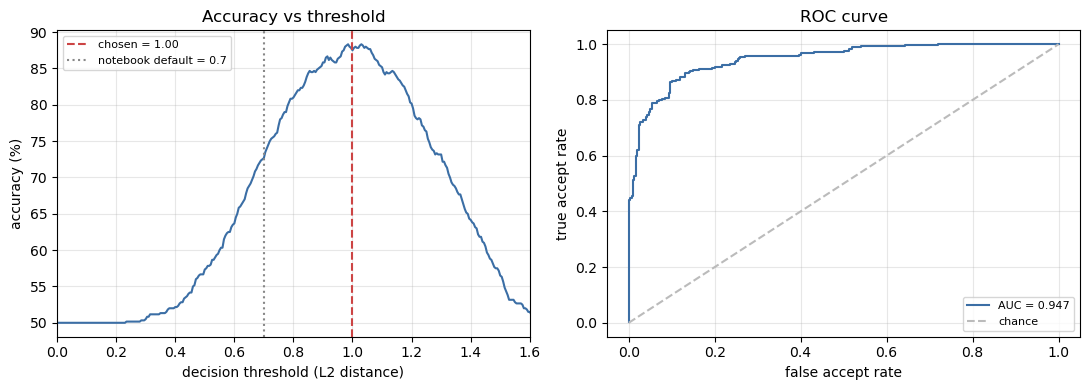

In [30]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))

grid, accuracies = results["sweep"]
left.plot(grid, accuracies * 100, color="#3b6ea5")
left.axvline(results["threshold_mean"], ls="--", c="#c44",
             label=f"chosen = {results['threshold_mean']:.2f}")
left.axvline(UNLOCK_THRESHOLD, ls=":", c="#888",
             label=f"notebook default = {UNLOCK_THRESHOLD}")
left.set(xlabel="decision threshold (L2 distance)", ylabel="accuracy (%)",
         title="Accuracy vs threshold", xlim=(0, 1.6))
left.legend(fontsize=8)
left.grid(alpha=0.3)

fpr, tpr = results["roc"]
right.plot(fpr, tpr, color="#3b6ea5", label=f"AUC = {results['auc']:.3f}")
right.plot([0, 1], [0, 1], ls="--", c="#bbb", label="chance")
right.set(xlabel="false accept rate", ylabel="true accept rate",
          title="ROC curve")
right.legend(fontsize=8)
right.grid(alpha=0.3)

fig.tight_layout()
plt.show()

### 7.3 Rank-1 identification accuracy

Verification is the easier task, a coin flip already scores 50%. Identification asks
the system to pick the right person out of a whole gallery, so random guessing scores
`1/N`. We build a gallery of people who have at least two photographs, enrol one image
each, and use the other as a query.

Note that identification accuracy depends on gallery size: the more people enrolled,
the more opportunities there are for a nearer wrong answer.

In [31]:
# People with 2+ photographs: one becomes the gallery entry, one the query.
# (LFW_ROOT was already defined back in section 1's setup cell.)
people_with_multiple = []
for person_dir in sorted(LFW_ROOT.iterdir()):
    shots = sorted(person_dir.glob("*.jpg"))
    if len(shots) >= 2:
        people_with_multiple.append((person_dir.name, shots[0], shots[1]))

rng = np.random.default_rng(0)
chosen = rng.choice(len(people_with_multiple), size=150, replace=False)
subset = [people_with_multiple[i] for i in chosen]

gallery_names = [name for name, _, _ in subset]
gallery_vectors = encode_many([str(g) for _, g, _ in subset], face_encoder,
                              crop=LFW_FACE_CROP)
probe_vectors = encode_many([str(p) for _, _, p in subset], face_encoder,
                            crop=LFW_FACE_CROP)

print(f"gallery: {len(gallery_names)} identities, one photo each")
print(f"probes : {len(gallery_names)} unseen photos of those same people")

gallery: 150 identities, one photo each
probes : 150 unseen photos of those same people


In [32]:
rank1, predictions = rank1_identification(gallery_names, gallery_vectors,
                                          gallery_names, probe_vectors)

print(f"rank-1 identification accuracy : {rank1*100:.2f}%")
print(f"chance baseline                : {100/len(gallery_names):.2f}%")
print(f"correct                        : {int(rank1*len(gallery_names))}"
      f"/{len(gallery_names)}")

wrong = [(t, p) for t, p in zip(gallery_names, predictions) if t != p]
print(f"\nfirst few mistakes (true -> predicted):")
for true_name, predicted_name in wrong[:5]:
    print(f"   {true_name:<28} -> {predicted_name}")

rank-1 identification accuracy : 58.67%
chance baseline                : 0.67%
correct                        : 88/150

first few mistakes (true -> predicted):
   James_Kopp                   -> Andy_Roddick
   Edmund_Stoiber               -> Larry_Bowa
   Franz_Muentefering           -> Eddie_Sutton
   Henrique_Meirelles           -> Silvio_Berlusconi
   Catherine_Zeta-Jones         -> Miguel_Contreras


### 7.3b Crop vs. plain downscale, measured on identification

The face crop was tuned on the *verification* pairs, and applied to identification on
the assumption that better embeddings help both tasks equally. That is an assumption,
not a measurement -- so here it is measured directly. Same 150 gallery/probe images,
same model; the only thing that changes is whether each 250x250 photo is cropped to
the face first or simply downscaled whole.

In [33]:
gallery_vectors_full = encode_many([str(g) for _, g, _ in subset], face_encoder,
                                   crop=None)
probe_vectors_full = encode_many([str(p) for _, _, p in subset], face_encoder,
                                 crop=None)

rank1_full, predictions_full = rank1_identification(
    gallery_names, gallery_vectors_full, gallery_names, probe_vectors_full)

In [34]:
print(f"{'preprocessing':<28} {'rank-1':>8}")
print(f"{'downscale only (no crop)':<28} {rank1_full*100:7.2f}%")
print(f"{'cropped to face':<28} {rank1*100:7.2f}%")
print(f"{'difference':<28} {(rank1 - rank1_full)*100:+7.2f} points")

preprocessing                  rank-1
downscale only (no crop)        3.33%
cropped to face                58.67%
difference                    +55.33 points


The direction matches the verification result -- cropping helps identification too --
which confirms the assumption rather than merely inheriting it. Whether the *size* of
the gain also matches verification's ~27 points is worth checking explicitly, since
identification pressure-tests the embedding differently (nearest of many, not one
threshold), so there's no guarantee the two tasks would move by the same amount.

### Why is that number so much lower than 87%?

A rank-1 figure in the fifties looks alarming next to 87% verification accuracy, but
the two are not measuring comparable things and the gap is mostly structural rather
than a sign the model is broken. Three measurements make the reason concrete.

**First: rank-1 is a function of gallery size.** Verification always compares against
exactly one stored face. Identification compares against every enrolled person, so each
additional identity is another opportunity for someone else to be nearer. Quoting
rank-1 without the gallery size is close to meaningless.

In [35]:
distances_probe_gallery = distance_matrix(probe_vectors, gallery_vectors)

sizes, means, deviations = rank1_vs_gallery_size(
    distances_probe_gallery,
    sizes=[2, 5, 10, 25, 50, 100, len(gallery_names)],
    trials=25,
)

print(f"{'gallery':>8}  {'rank-1':>8}  {'chance':>8}")
for size, mean, deviation in zip(sizes, means, deviations):
    print(f"{size:>8}  {mean*100:6.2f}%  {100/size:7.2f}%   (+/- {deviation*100:.1f})")

 gallery    rank-1    chance
       2  100.00%    50.00%   (+/- 0.0)
       5   85.60%    20.00%   (+/- 13.3)
      10   80.00%    10.00%   (+/- 11.3)
      25   74.08%     4.00%   (+/- 7.3)
      50   66.24%     2.00%   (+/- 6.0)
     100   60.60%     1.00%   (+/- 3.0)
     150   58.67%     0.67%   (+/- 0.0)


The same model, the same photographs, the same embeddings, only the number of people
it has to choose between changes. Against 2 candidates it is highly reliable; against
150 it is not. Nothing about the network changed in between.

**Second: the failures are concentrated, not uniform.** If the model were uniformly
mediocre, the correct identity would sit at a random rank. Instead the median rank of
the correct person is near the top and the mean is dragged up by a small tail of
badly-framed or badly-lit probes.

In [36]:
ranks = identification_ranks(distances_probe_gallery)

print(f"{'metric':<28} {'value':>8}")
for k in (1, 2, 3, 5, 10, 25):
    print(f"top-{k} accuracy{'':<15} {(ranks < k).mean()*100:7.2f}%")
print(f"{'median rank of truth':<28} {np.median(ranks):8.0f}")
print(f"{'mean rank of truth':<28} {ranks.mean():8.1f}")

metric                          value
top-1 accuracy                  58.67%
top-2 accuracy                  64.67%
top-3 accuracy                  67.33%
top-5 accuracy                  76.00%
top-10 accuracy                  82.67%
top-25 accuracy                  90.00%
median rank of truth                0
mean rank of truth                6.5


Read that table as: the correct person is usually *nearly* first even when not first.
A system that shortlists a handful of candidates for a human to confirm performs far
better than the rank-1 number suggests, which is how identification is actually
deployed in practice.

**Third: the per-comparison error rate is small.** The quantity that describes the
embedding quality independently of gallery size is: given one probe and one random
wrong person, how often is the wrong person closer than the right one?

In [37]:
n_probes = len(distances_probe_gallery)
true_distances = distances_probe_gallery[np.arange(n_probes), np.arange(n_probes)]

per_comparison_error = np.mean([
    (distances_probe_gallery[i][np.arange(n_probes) != i] < true_distances[i]).mean()
    for i in range(n_probes)
])

print(f"P(a random wrong person is closer than the right one) = "
      f"{per_comparison_error*100:.2f}%")
print(f"if those errors were independent, rank-1 over {n_probes - 1} distractors "
      f"would be {(1 - per_comparison_error)**(n_probes - 1)*100:.2f}%")
print(f"actual rank-1 = {rank1*100:.2f}%")

P(a random wrong person is closer than the right one) = 4.34%
if those errors were independent, rank-1 over 149 distractors would be 0.13%
actual rank-1 = 58.67%


That last comparison is the interesting one. The independence assumption predicts a
far *worse* result than we actually observe, which tells us the errors are strongly
correlated: a handful of difficult probes account for most of the failures, while the
majority are matched comfortably. Averaged accuracy hides that structure completely.

**What would actually improve it**, roughly in order of expected payoff:

1. **Landmark-based alignment** instead of a fixed centre crop. This is the single
   biggest gap between this pipeline and the published 99.6%, a rotated or off-centre
   face is poorly framed by a fixed box no matter how well the box is tuned.
2. **Multiple photos per enrolled identity**, averaged into one template. Enrolling one
   photo means one pose and one lighting condition defines that person forever.
3. **A larger backbone.** `nn4.small2` is a compact 2015-era model, 3.7M parameters at
   96x96 input. Modern face encoders are an order of magnitude larger and take 160x160
   or higher.

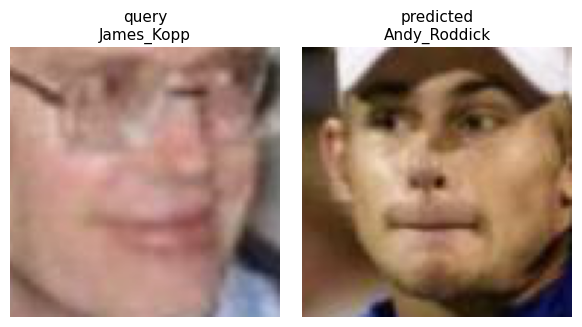

In [38]:
# Look at one mistake. Confusions are usually intelligible -- similar pose,
# lighting or hair rather than arbitrary noise.
if wrong:
    true_name, predicted_name = wrong[0]
    query_image = next(p for n, _, p in subset if n == true_name)
    matched_image = next(g for n, g, _ in subset if n == predicted_name)
    show_face_pair(query_image, matched_image,
                   probe_label=f"query\n{true_name}",
                   match_label=f"predicted\n{predicted_name}",
                   accepted=False, crop=LFW_FACE_CROP)
else:
    print("no mistakes in this sample")